# this notebook generates the plots comparing tcrdist using TCRab, TCRa, or TCRb information 

figure S3

### imports

In [ ]:
import json
import pandas as pd
import os
import numpy as np
import random
from pathlib import Path 
import sys
# from Bio.Data import IUPACData
from matplotlib import pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix,ConfusionMatrixDisplay, confusion_matrix
import seaborn as sns


### set params

In [ ]:
output_path = 'a_or_b_only_tcrdist'
path_to_labels = 'experiment_set_stats_all-v-1.json'
path_to_scores_file = 'tcr_production_val_nonval_v4/df_alphabridge_pre_msa_tcr_production_val_nonval_v4.csv'
path_to_labels_tetra = 'experiment_set_stats_tetramer_all-v-1.json'
# read from json name_color_dict
with open('name_color_dict_rebuttal.json', 'r') as f:
    name_color_dict = json.load(f)

In [ ]:
import pandas as pd
labels_all_epitopes = pd.read_json(path_to_labels)
labels_all_epitopes_tetra = pd.read_json(path_to_labels_tetra)
scores_all_epitopes = pd.read_csv(path_to_scores_file)

In [ ]:
path_to_tcrdist_scores = 'tcrdist_ab-a-b_modalities/out'

import glob
import pandas as pd

tcrdist_preds = {}
for csv in glob.glob(path_to_tcrdist_scores + "/*.csv"):
    modality = csv.split("/")[-1].split("_")[-1].split(".")[0]
    print(modality)
    epitope = csv.split("/")[-1].split("_")[0]
    
    if modality not in tcrdist_preds:
        tcrdist_preds[modality] = {}
    
    df = pd.read_csv(csv)
    df['label'] = df['name'].str.upper().apply(lambda x: 1 if x in labels_all_epitopes[epitope].T['pos_ids'] else 0)

    print(epitope, len(labels_all_epitopes[epitope].T['pos_ids']), len(labels_all_epitopes[epitope].T['neg_ids']))
    tcrdist_preds[modality][epitope] = df.copy()

tcr_dist_preds_orig = tcrdist_preds.copy()

ab
GILGFVFTL 381 199
a
TTDPSFLGRY 170 174
b
GLCTLVAML 110 59
b
LTDEMIAQY 75 52
b
TTDPSFLGRY 170 174
a
GLCTLVAML 110 59
ab
TTDPSFLGRY 170 174
a
LTDEMIAQY 75 52
a
NLVPMVATV 91 231
b
CINGVCWTV 174 54
ab
LTDEMIAQY 75 52
b
NLVPMVATV 91 231
a
CINGVCWTV 174 54
a
LLWNGPMAV 162 53
ab
NLVPMVATV 91 231
ab
LLWNGPMAV 162 53
b
LLWNGPMAV 162 53
b
YLQPRTFLL 158 231
ab
CINGVCWTV 174 54
a
YLQPRTFLL 158 231
a
GILGFVFTL 381 199
b
GILGFVFTL 381 199
ab
GLCTLVAML 110 59
ab
YLQPRTFLL 158 231


### set plotting params

In [ ]:
from matplotlib import rcParams
import matplotlib as mpl
from matplotlib import pyplot as plt
import matplotlib.font_manager as fm 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, rankdata
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, rankdata
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, roc_auc_score, roc_curve, precision_recall_curve, average_precision_score

def set_mpl_params(mpl):
    mylines = 0.75 # pt updated
    mpl.rcParams['axes.linewidth'] = mylines # default 1
    mpl.rcParams['ytick.direction'] = 'out' # default 'in'
    mpl.rcParams['xtick.direction'] = 'out' # default 'in'
    mpl.rcParams['xtick.major.size'] = 3.5 # default 4
    mpl.rcParams['ytick.major.size'] = 3.5 # default 4
    mpl.rcParams['xtick.major.width'] = mylines # default 0.5
    mpl.rcParams['ytick.major.width'] = mylines # default 0.5
    mpl.rcParams['grid.linewidth'] = mylines/1.5# default 0.5
    mpl.rcParams['grid.color'] = '0.8' # default 'k'
    mpl.rcParams['grid.linestyle'] = 'solid'# default ':'
    mpl.rcParams['legend.frameon'] = False # default True
    mpl.rcParams['font.family'] = 'Arial' # added
    mpl.rcParams['figure.dpi']= 300
    mpl.rc("savefig", dpi=300)
    mpl.rcParams['pdf.fonttype'] = 42 # embed fonts as editable text in illustrator
    mpl.rcParams['ps.fonttype'] = 42 # embed fonts as editable text in illustrator
    mpl.rcParams['figure.autolayout'] = True  # set tight layout to always true

    mpl.rcParams['xtick.labelsize'] = 7  # X-axis tick labels
    mpl.rcParams['ytick.labelsize'] = 7  # Y-axis tick labels

    return mpl, mylines

out_path_dropbox = '/Users/b.kwee/schumacher_lab Dropbox/schumi/ts/ts6_STAPLER_TCRs_top-10-epitopes_validation/publication/figures/illustrator_figures/v2/figures/bjorn_v2/auc/'
import os
if not os.path.exists(out_path_dropbox):
    os.makedirs(out_path_dropbox)


SAVE_DROPBOX = True
fm.fontManager.addfont("/Library/Fonts/Arial Unicode.ttf")
mpl, mylines = set_mpl_params(mpl)



SAVE_FIGS = True

fm.fontManager.addfont("/Library/Fonts/Arial Unicode.ttf") 
mpl, mylines = set_mpl_params(mpl)

figsize_prc_auc = (5/2.54, 4/2.54)
dotsize = 12
fontsize_axes = 7

background_alpha = 0.45
color_alpha = 0.6


{'tcrdist3': 0.8030572811564383}


/Users/b.kwee/miniconda3/envs/mlenv_update/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


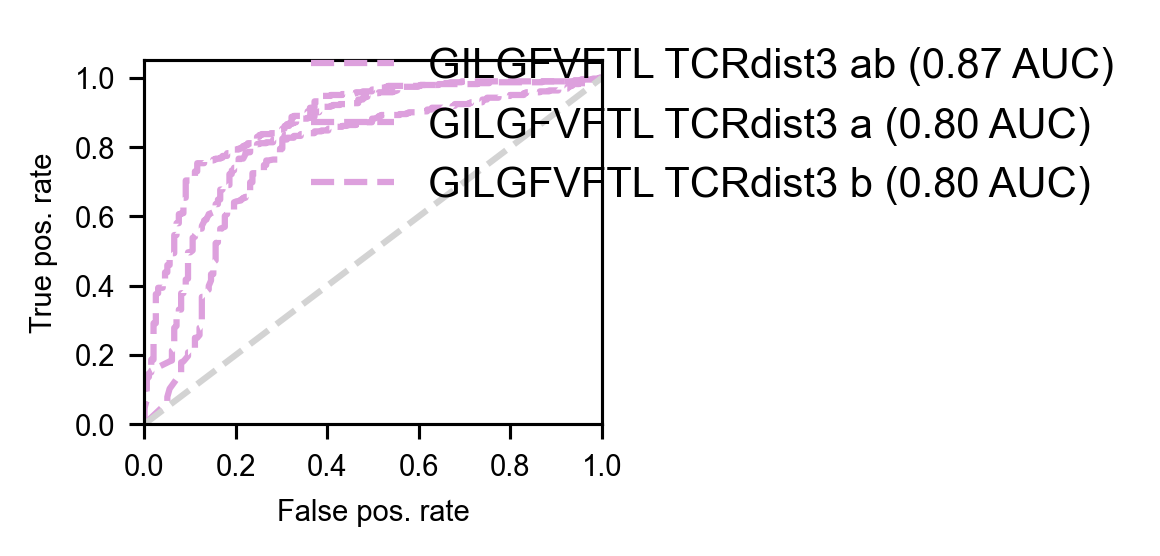

{'tcrdist3': 0.6315513626834381}


/Users/b.kwee/miniconda3/envs/mlenv_update/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


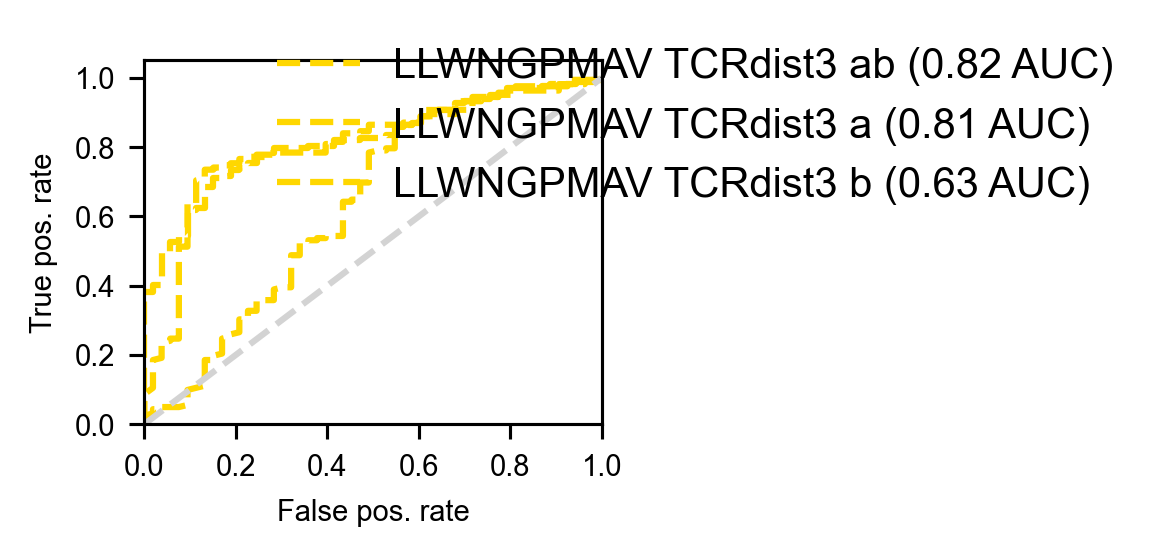

/Users/b.kwee/miniconda3/envs/mlenv_update/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


{'tcrdist3': 0.545}


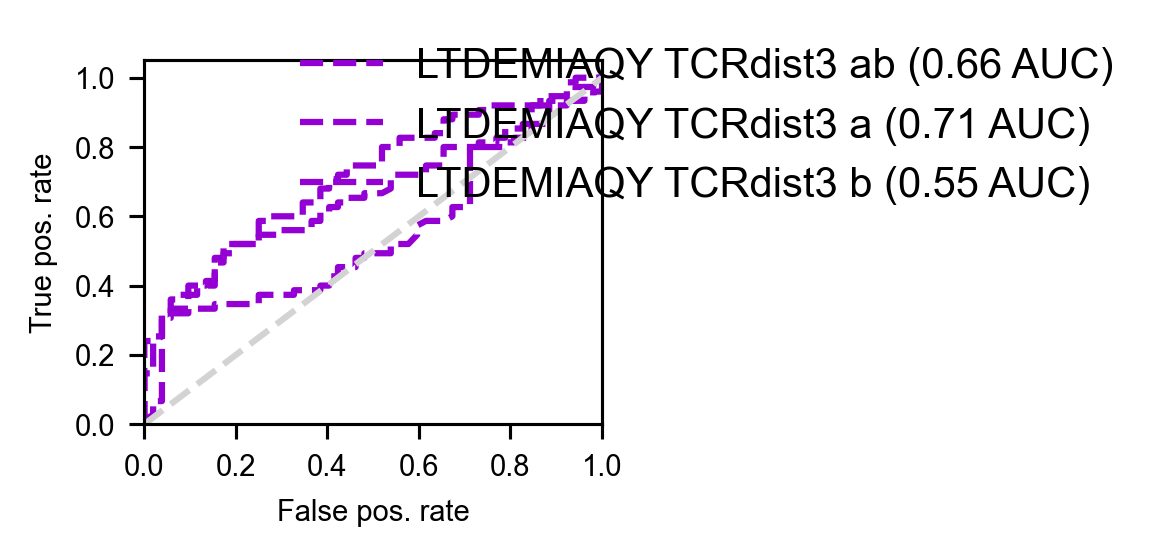

{'tcrdist3': 0.5473805855161787}


/Users/b.kwee/miniconda3/envs/mlenv_update/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


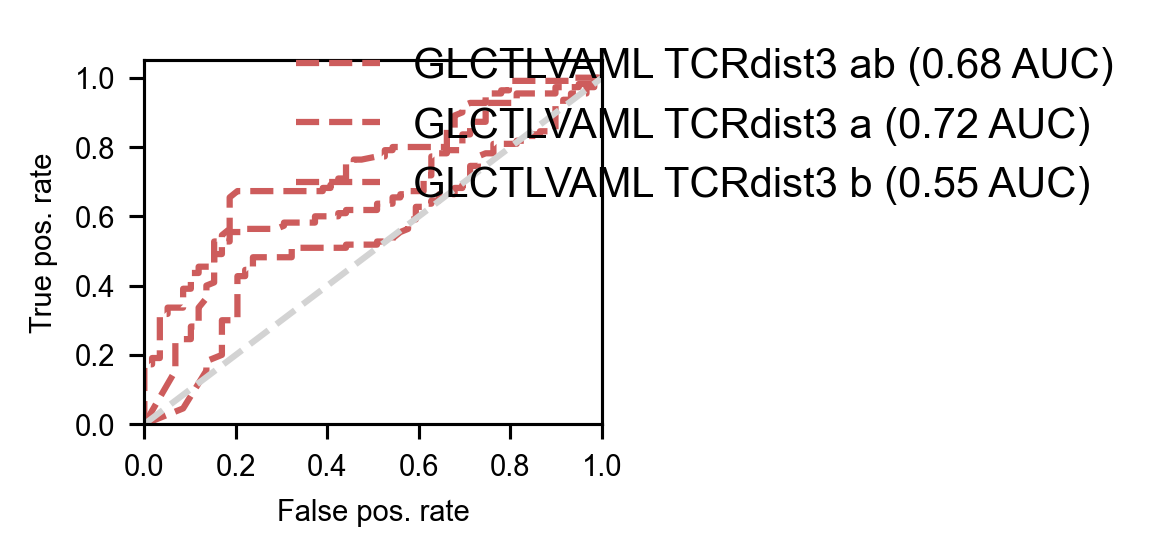

{'tcrdist3': 0.8414296673790345}


/Users/b.kwee/miniconda3/envs/mlenv_update/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


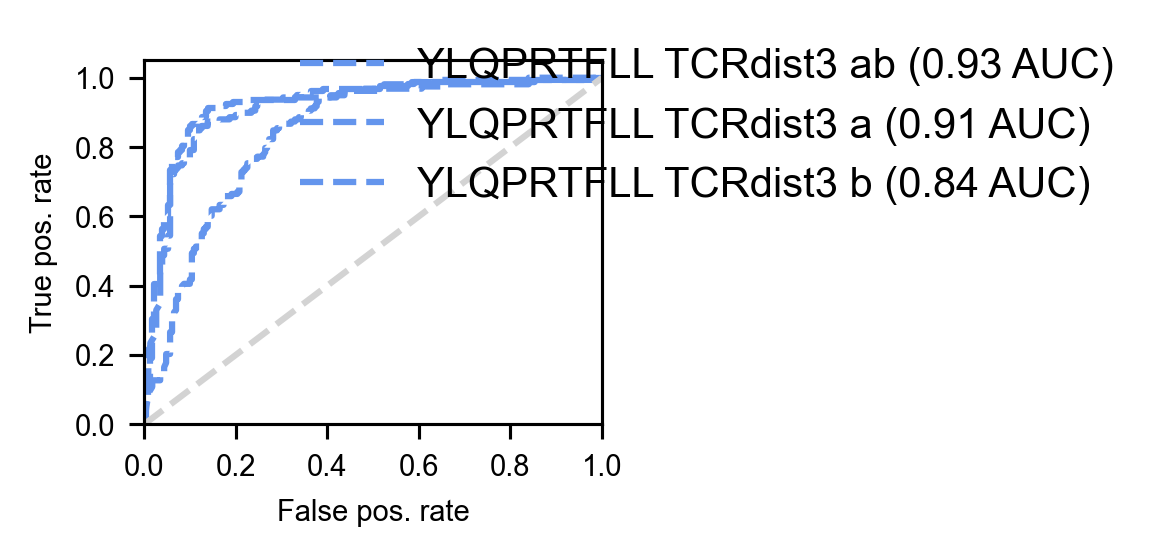

{'tcrdist3': 0.7424104124408384}


/Users/b.kwee/miniconda3/envs/mlenv_update/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


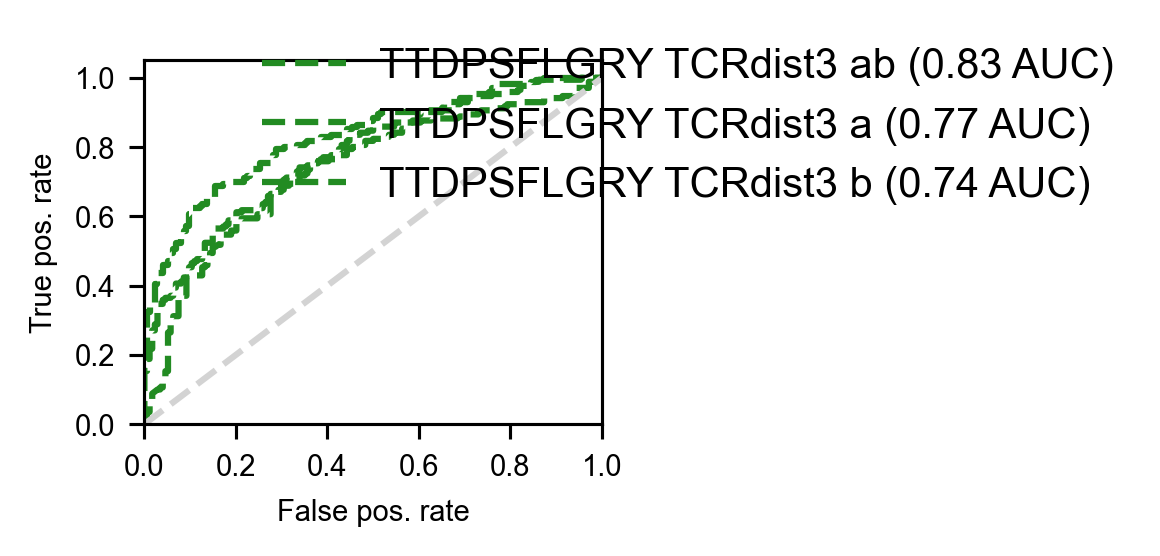

{'tcrdist3': 0.7367632367632367}


/Users/b.kwee/miniconda3/envs/mlenv_update/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


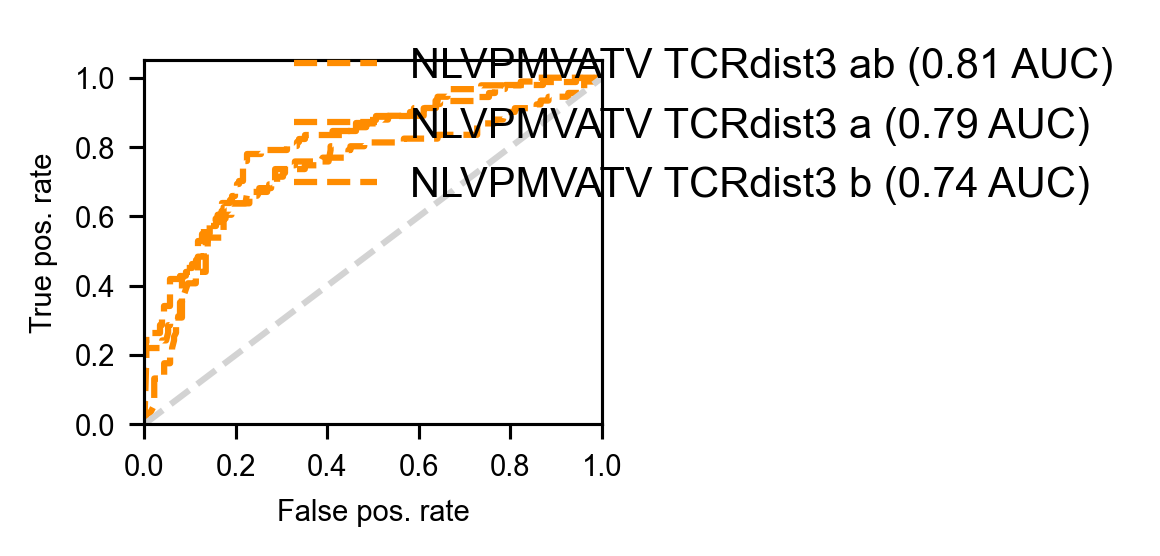

{'tcrdist3': 0.60291613452533}


/Users/b.kwee/miniconda3/envs/mlenv_update/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


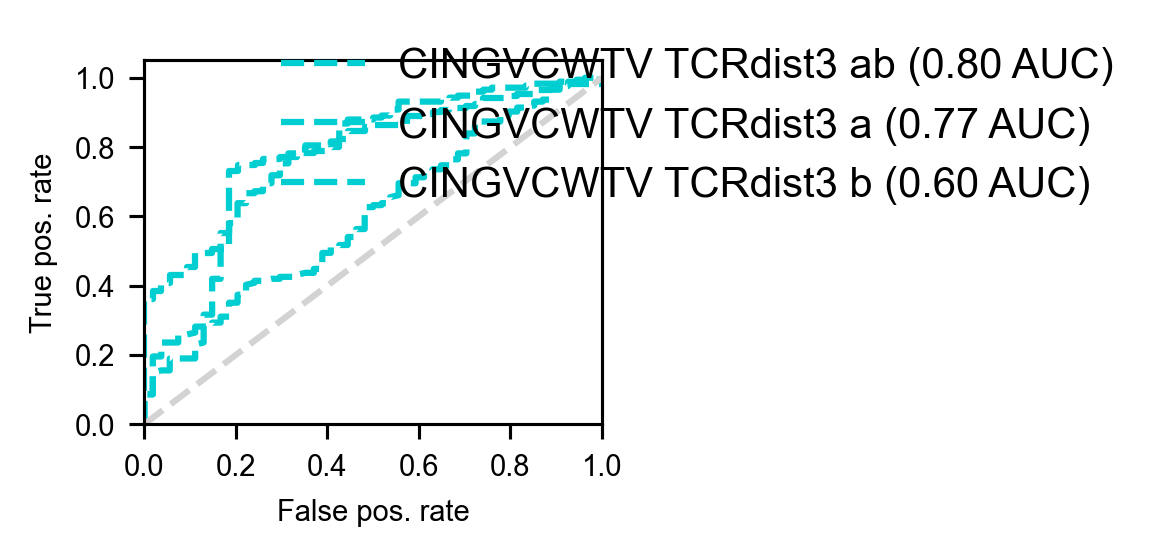

In [ ]:

all_scores = []
for column_epi in labels_all_epitopes.columns:
   for label_type, label_dict in zip(['functional'], [labels_all_epitopes]):

      plt.figure(figsize=figsize_prc_auc)
      roc_auc = {}
      if label_type == 'tetramer' and column_epi not in ['YLQPRTFLL', 'GLCTLVAML']:
         continue
      elif label_type == 'tetramer':
         print(f'Plotting tetramer labels for {column_epi}')
      for model in ['tcrdist3', 'TCRbridge']:
         if model == 'TCRbridge':
            pass
         elif model == 'tcrdist3':
            for modality in tcrdist_preds.keys():
               subset_df = tcrdist_preds[modality][column_epi].copy()
               labels = label_dict[column_epi].T
               pos_ids = labels['pos_ids']
               neg_ids = labels['neg_ids']
               subset_df = subset_df[subset_df['name'].str.upper().isin(pos_ids + neg_ids)].copy()

               subset_df['label'] = subset_df['name'].str.upper().apply(lambda x: 1 if x in pos_ids else 0)

               y_true = subset_df['label']
               y_scores = -subset_df['prediction']  # invert distance to get score
               roc_auc[model] = roc_auc_score(y_true, y_scores)
               fpr, tpr, _ = roc_curve(y_true, y_scores)
               plt.plot(fpr, tpr, alpha=1, label=f'{column_epi} TCRdist3 {modality} ({roc_auc[model]:.2f} AUC)', color=name_color_dict[column_epi], linestyle='--')

      plt.xlabel('False pos. rate', fontsize=fontsize_axes)
      plt.ylabel('True pos. rate', fontsize=fontsize_axes)

      # plt.grid(True)
      plt.ylim(0, 1.05)
      plt.xlim(0, 1.0)
      plt.legend(loc='lower right', bbox_to_anchor=(2.2, 0.5))

      print(roc_auc)
      plt.plot([0, 1], [0, 1], color='lightgrey', linestyle='--', label=f'Random (0.50 AUC)')


      plt.show()
      plt.close()


In [61]:
# import mcolors
from matplotlib import colors as mcolors

name_color_dict = {k: v for k, v in name_color_dict.items() if v != 'TBD' and v != 'other'}
# only if in epitopes
name_color_dict = {k: v for k, v in name_color_dict.items() if k in labels_all_epitopes.columns}


def darken_color(color_name, factor=0.7):
    rgb = mcolors.to_rgb(color_name)
    darker_rgb = tuple(max(0, c * factor) for c in rgb)
    return mcolors.to_hex(darker_rgb)

def lighten_color(color_name, factor=0.2):
    rgb = mcolors.to_rgb(color_name)
    lighter_rgb = tuple(c + (1 - c) * factor for c in rgb)
    return mcolors.to_hex(lighter_rgb)


name_color_dict_darker = {}
for name, color in name_color_dict.items():
    name_color_dict_darker[name] = darken_color(color, factor=0.6)  

name_color_dict_lighter = {}
for name, color in name_color_dict.items():
    name_color_dict_lighter[name] = lighten_color(color, factor=0.65)
    

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# To store results: rows = epitopes, columns = model/modalities
results = []

for column_epi in labels_all_epitopes.columns:
    for label_type, label_dict in zip(['functional'], [labels_all_epitopes]):

        roc_auc = {}

        model = 'tcrdist3'
        for modality in tcrdist_preds.keys():
            subset_df = tcrdist_preds[modality][column_epi].copy()
            labels = label_dict[column_epi].T
            pos_ids = labels['pos_ids']
            neg_ids = labels['neg_ids']

            subset_df = subset_df[subset_df['name'].str.upper().isin(pos_ids + neg_ids)].copy()
            subset_df['label'] = subset_df['name'].str.upper().apply(lambda x: 1 if x in pos_ids else 0)

            y_true = subset_df['label']
            y_scores = -subset_df['prediction']

            roc_auc[f"{model}_{modality}"] = roc_auc_score(y_true, y_scores)

        # Store results for bar plot
        for k, v in roc_auc.items():
            results.append([column_epi, k, v])

# Convert to DataFrame
df = pd.DataFrame(results, columns=["Epitope", "Model", "AUC"])


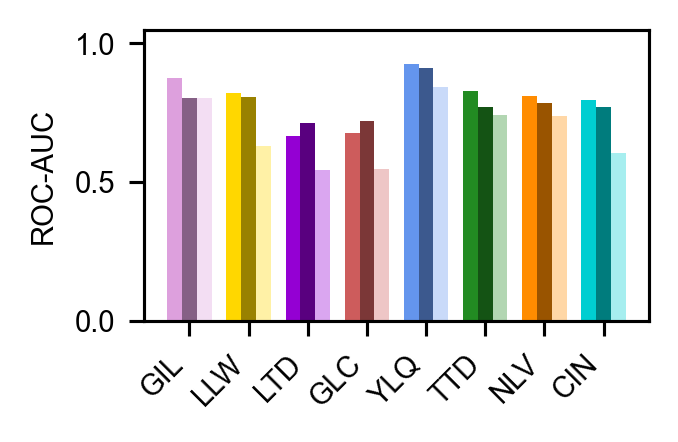

In [99]:
# plt.figure(figsize=(6/2.54, 4/2.54))
plt.figure(figsize=(6/2.54, 4/2.54))

bar_width = 0.25

models = ['tcrdist3_ab', 'tcrdist3_a', 'tcrdist3_b']
epitopes = df["Epitope"].unique()
x = np.arange(len(epitopes))
for i, model in enumerate(models):
    subset = df[df["Model"] == model].copy()
    # Ensure same epitope ordering
    subset = subset.set_index("Epitope").loc[epitopes].reset_index()

    # Map color per epitope
    if model == 'tcrdist3_ab':
        colors = [name_color_dict[e] for e in subset["Epitope"]]
    elif model == 'tcrdist3_a':
        colors = [name_color_dict_darker[e] for e in subset["Epitope"]]
    else:
        colors = [name_color_dict_lighter[e] for e in subset["Epitope"]]

    plt.bar(x + i*bar_width, subset["AUC"], width=bar_width, label=model, color=colors)

#only first 3 letters of epitope
plt.xticks(x + bar_width, [e[:3] for e in epitopes], rotation=45, ha='right',  fontsize=fontsize_axes)

plt.ylabel("ROC-AUC", fontsize=fontsize_axes)
plt.ylim(0.0, 1.05)

plt.tight_layout()
# savefig
if SAVE_FIGS:
    plt.savefig(os.path.join(output_path, 'roc_auc_tcrdist3_ab_a_b_only.pdf'), dpi=300, bbox_inches='tight')
plt.show()

In [ ]:

import pandas as pd
ref_df = pd.read_csv('ref_df_subset_on_fasta_3693_eight_epi_labeled.csv')
for epi in ref_df['epitope_aa'].unique():
    subset_df = ref_df[ref_df['epitope_aa'] == epi].copy()
    val_subset_df = subset_df[subset_df['label_ambig-is-neg']].copy()
    nonval_subset_df = subset_df[~subset_df['label_ambig-is-neg']].copy()
    uniqe_alpha_vals = val_subset_df['cdr3_alpha_aa'].nunique()
    uniqe_beta_vals = val_subset_df['cdr3_beta_aa'].nunique()
    print()
    print(epi, 'val', val_subset_df.shape, 'unique alpha:', uniqe_alpha_vals, 'unique beta:', uniqe_beta_vals)
    uniqe_alpha_vals_nonval = nonval_subset_df['cdr3_alpha_aa'].nunique()
    uniqe_beta_vals_nonval = nonval_subset_df['cdr3_beta_aa'].nunique()
    print(epi, 'nonval', nonval_subset_df.shape, 'unique alpha:', uniqe_alpha_vals_nonval, 'unique beta:', uniqe_beta_vals_nonval)


    # print the intersection of cdr3_alpha_aa and cdr3_beta_aa between val and nonval
    intersect_alpha = set(val_subset_df['cdr3_alpha_aa']).intersection(set(nonval_subset_df['cdr3_alpha_aa']))
    intersect_beta = set(val_subset_df['cdr3_beta_aa']).intersection(set(nonval_subset_df['cdr3_beta_aa']))
    print(epi, 'intersection alpha:', len(intersect_alpha), 'intersection beta:', len(intersect_beta))

    # print as a ratio to the total unique values in val
    if uniqe_alpha_vals > 0:
        print(epi, 'intersection alpha ratio:', len(intersect_alpha)/uniqe_alpha_vals)
    if uniqe_beta_vals > 0:
        print(epi, 'intersection beta ratio:', len(intersect_beta)/uniqe_beta_vals) 



GILGFVFTL val (381, 52) unique alpha: 256 unique beta: 243
GILGFVFTL nonval (294, 52) unique alpha: 242 unique beta: 225
GILGFVFTL intersection alpha: 37 intersection beta: 41
GILGFVFTL intersection alpha ratio: 0.14453125
GILGFVFTL intersection beta ratio: 0.16872427983539096

LLWNGPMAV val (162, 52) unique alpha: 134 unique beta: 159
LLWNGPMAV nonval (70, 52) unique alpha: 70 unique beta: 67
LLWNGPMAV intersection alpha: 2 intersection beta: 10
LLWNGPMAV intersection alpha ratio: 0.014925373134328358
LLWNGPMAV intersection beta ratio: 0.06289308176100629

LTDEMIAQY val (75, 52) unique alpha: 66 unique beta: 74
LTDEMIAQY nonval (57, 52) unique alpha: 57 unique beta: 57
LTDEMIAQY intersection alpha: 1 intersection beta: 4
LTDEMIAQY intersection alpha ratio: 0.015151515151515152
LTDEMIAQY intersection beta ratio: 0.05405405405405406

GLCTLVAML val (110, 52) unique alpha: 76 unique beta: 90
GLCTLVAML nonval (85, 52) unique alpha: 71 unique beta: 70
GLCTLVAML intersection alpha: 12 inter